In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

In [4]:
import kagglehub
path = kagglehub.dataset_download("shreyapmaher/fruits-dataset-images")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'fruits-dataset-images' dataset.
Path to dataset files: /kaggle/input/fruits-dataset-images


In [5]:
import os
for root, dirs, files in os.walk(path):
    print("ROOT:", root)
    print("FOLDERS:", dirs[:10])
    print("FILES:", len(files))
    print("-" * 50)
    if root.count(os.sep) - path.count(os.sep) >= 2:
        break

ROOT: /kaggle/input/fruits-dataset-images
FOLDERS: ['images']
FILES: 0
--------------------------------------------------
ROOT: /kaggle/input/fruits-dataset-images/images
FOLDERS: ['apple fruit', 'orange fruit', 'strawberry fruit', 'grapes fruit', 'banana fruit', 'cherry fruit', 'kiwi fruit', 'mango fruit', 'chickoo fruit']
FILES: 0
--------------------------------------------------
ROOT: /kaggle/input/fruits-dataset-images/images/apple fruit
FOLDERS: []
FILES: 40
--------------------------------------------------


In [6]:
import tensorflow as tf
dataset_path = os.path.join(path, "images")
dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    image_size=(128, 128),
    batch_size=32,
    shuffle=True
)

print("Classes:", dataset.class_names)

Found 360 files belonging to 9 classes.
Classes: ['apple fruit', 'banana fruit', 'cherry fruit', 'chickoo fruit', 'grapes fruit', 'kiwi fruit', 'mango fruit', 'orange fruit', 'strawberry fruit']


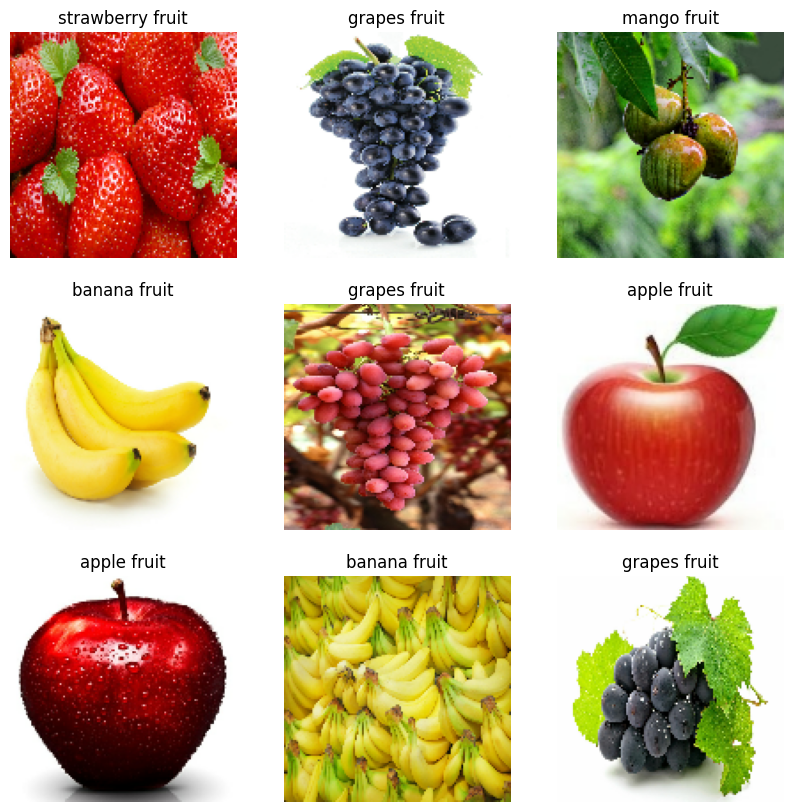

In [7]:
plt.figure(figsize=(10, 10))
for images, labels in dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(dataset.class_names[labels[i]])
        plt.axis("off")
plt.show()

In [8]:
for images, labels in dataset.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("One image shape:", images[0].shape)

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)
One image shape: (128, 128, 3)


In [9]:
dataset_path = os.path.join(path, "images")
classes = os.listdir(dataset_path)
print("Number of classes:", len(classes))
print("Classes:", classes)
for cls in classes:
    folder = os.path.join(dataset_path, cls)
    print(cls, ":", len(os.listdir(folder)), "images")

Number of classes: 9
Classes: ['apple fruit', 'orange fruit', 'strawberry fruit', 'grapes fruit', 'banana fruit', 'cherry fruit', 'kiwi fruit', 'mango fruit', 'chickoo fruit']
apple fruit : 40 images
orange fruit : 40 images
strawberry fruit : 40 images
grapes fruit : 40 images
banana fruit : 40 images
cherry fruit : 40 images
kiwi fruit : 40 images
mango fruit : 40 images
chickoo fruit : 40 images


In [10]:
from PIL import Image
corrupted = []
for cls in classes:
  folder = os.path.join(dataset_path, cls)
  for file in os.listdir(folder):
    file_path = os.path.join(folder, file)
    try:
      img = Image.open(file_path)
      img.verify()
    except:
      corrupted.append(file_path)
print(len(corrupted))
if corrupted:
  print(corrupted)

0


In [11]:
from PIL import Image
sizes = []
for cls in classes:
    folder = os.path.join(dataset_path, cls)
    for file in os.listdir(folder):
        file_path = os.path.join(folder, file)
        img = Image.open(file_path)
        sizes.append(img.size)
print("First 10 sizes:")
print(sizes[:10])
print("Number of different sizes:", len(set(sizes)))

First 10 sizes:
[(1200, 900), (2827, 2827), (744, 744), (1024, 768), (2000, 1244), (1920, 1200), (693, 693), (600, 600), (800, 745), (4800, 4742)]
Number of different sizes: 268


In [12]:
modes = {}
for cls in classes:
    folder = os.path.join(dataset_path, cls)
    for file in os.listdir(folder):
        file_path = os.path.join(folder, file)
        img = Image.open(file_path)
        modes[img.mode] = modes.get(img.mode, 0) + 1
print(modes)

{'RGB': 343, 'RGBA': 16, 'P': 1}


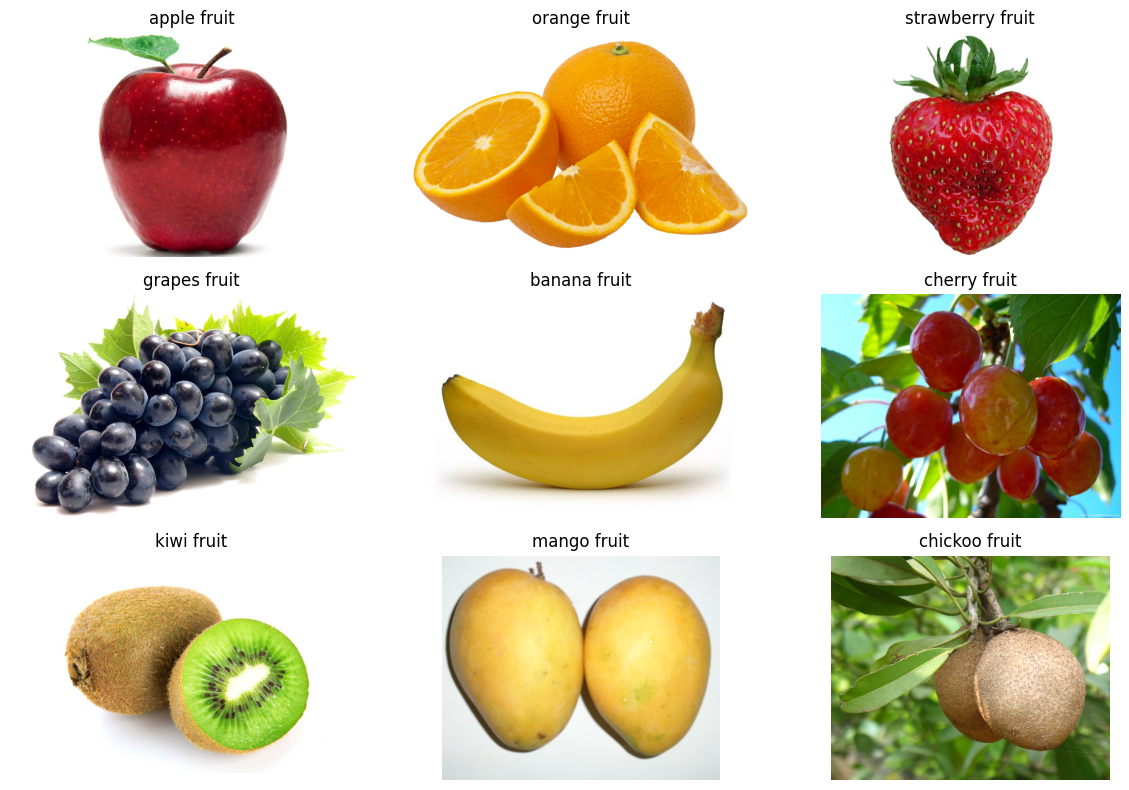

In [13]:
import matplotlib.pyplot as plt
import random
plt.figure(figsize=(12, 8))
for i, cls in enumerate(classes):
    folder = os.path.join(dataset_path, cls)
    file = random.choice(os.listdir(folder))
    img = Image.open(os.path.join(folder, file))
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
plt.tight_layout()
plt.show()

In [14]:
from PIL import Image
import os
clean_path = "/content/clean_fruits"
os.makedirs(clean_path, exist_ok=True)
for cls in classes:
    source_folder = os.path.join(dataset_path, cls)
    target_folder = os.path.join(clean_path, cls)
    os.makedirs(target_folder, exist_ok=True)
    for file in os.listdir(source_folder):
        source_file = os.path.join(source_folder, file)
        target_file = os.path.join(target_folder, file)
        try:
            img = Image.open(source_file)
            img = img.convert("RGB")
            img = img.resize((128, 128))
            img.save(target_file)
        except Exception as e:
            print("Error:", source_file, e)
print("Cleaning + resizing completed!")

Cleaning + resizing completed!


In [15]:
from PIL import Image
import os
sample_class = classes[0]
sample_folder = os.path.join(clean_path, sample_class)
sample_file = os.listdir(sample_folder)[0]
img = Image.open(os.path.join(sample_folder, sample_file))
print("Size:", img.size)
print("Mode:", img.mode)

Size: (128, 128)
Mode: RGB


In [16]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    clean_path,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32,
    shuffle=True
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    clean_path,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32,
    shuffle=True
)
class_names = train_ds.class_names
print("Classes:", class_names)
print("Number of classes:", len(class_names))

Found 360 files belonging to 9 classes.
Using 288 files for training.
Found 360 files belonging to 9 classes.
Using 72 files for validation.
Classes: ['apple fruit', 'banana fruit', 'cherry fruit', 'chickoo fruit', 'grapes fruit', 'kiwi fruit', 'mango fruit', 'orange fruit', 'strawberry fruit']
Number of classes: 9


In [17]:
normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(
    lambda x, y: (normalization_layer(x), y)
)
val_ds = val_ds.map(
    lambda x, y: (normalization_layer(x), y)
)
for images, labels in train_ds.take(1):
    print("Shape:", images.shape)
    print("Min:", tf.reduce_min(images).numpy())
    print("Max:", tf.reduce_max(images).numpy())

Shape: (32, 128, 128, 3)
Min: 0.0
Max: 1.0


In [18]:
data_augmentation = Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

In [19]:
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y)
)

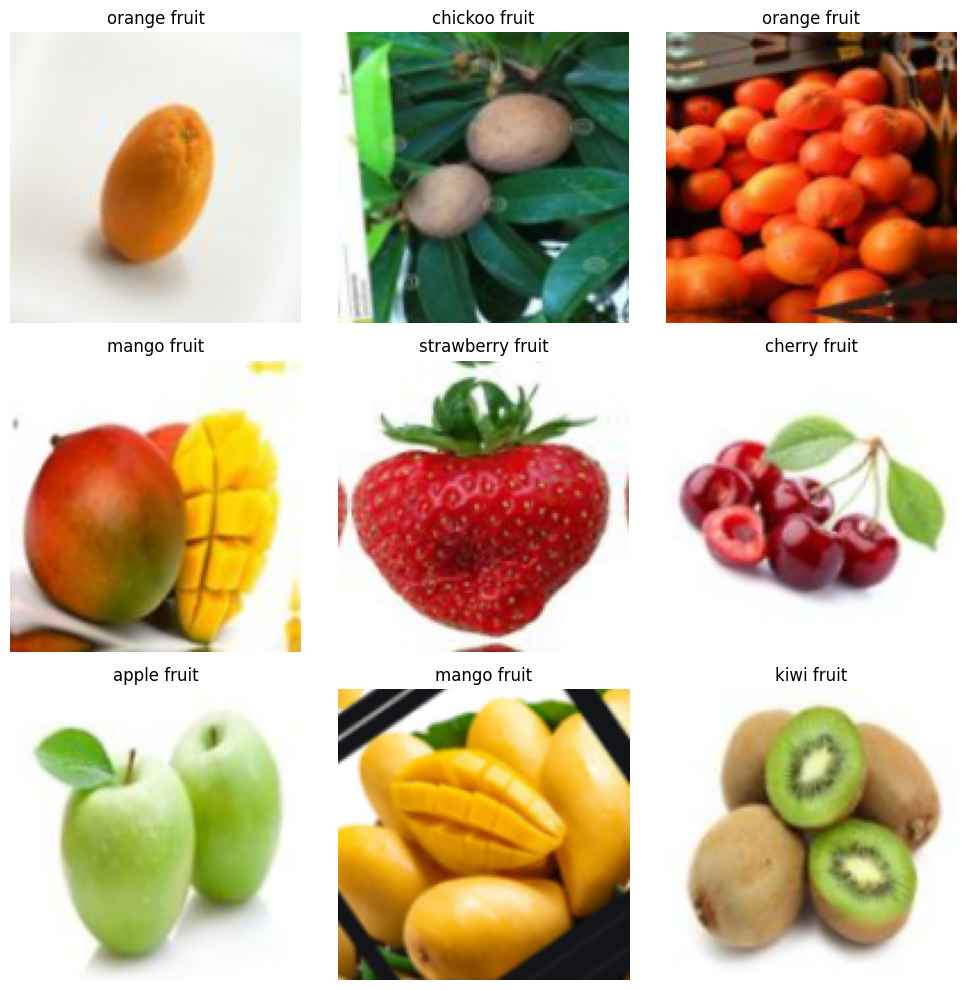

In [20]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):

    plt.figure(figsize=(10, 10))

    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy())
        plt.title(class_names[labels[i]])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [21]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

In [22]:
model = Sequential([
    Conv2D(
        32, (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),
    MaxPooling2D(
        pool_size=(2,2)
    ),
    Conv2D(
        64, (3,3),
        activation='relu'
    ),
    MaxPooling2D(
        pool_size=(2,2)
    ),
    Conv2D(
        128, (3,3),
        activation='relu'
    ),
    MaxPooling2D(
        pool_size=(2,2)
    ),
    Flatten(),
    Dense(
        128,
        activation='relu'
    ),
    Dropout(0.5),
    Dense(
        len(class_names),
        activation='softmax'
    )
])

In [23]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,801 (12.61 MB)

 Trainable params: 3,305,801 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.1319 - loss: 2.3213 - val_accuracy: 0.1389 - val_loss: 2.2007
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 978ms/step - accuracy: 0.1319 - loss: 2.1809 - val_accuracy: 0.1944 - val_loss: 2.1127
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 977ms/step - accuracy: 0.2569 - loss: 2.0144 - val_accuracy: 0.3750 - val_loss: 1.7861
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.3507 - loss: 1.7640 - val_accuracy: 0.4028 - val_loss: 1.7146
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.3646 - loss: 1.6444 - val_accuracy: 0.4028 - val_loss: 1.5872
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.3854 - loss: 1.5523 - val_accuracy: 0.4583 - val_loss: 1.6293
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 999ms/step - accuracy: 0.4826 - loss: 1.5244 - val_accuracy: 0.5694 - val_loss: 1.5405
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.4375 - loss: 1.4695 - val_accuracy: 0.4306 - val_loss: 1.7014
E

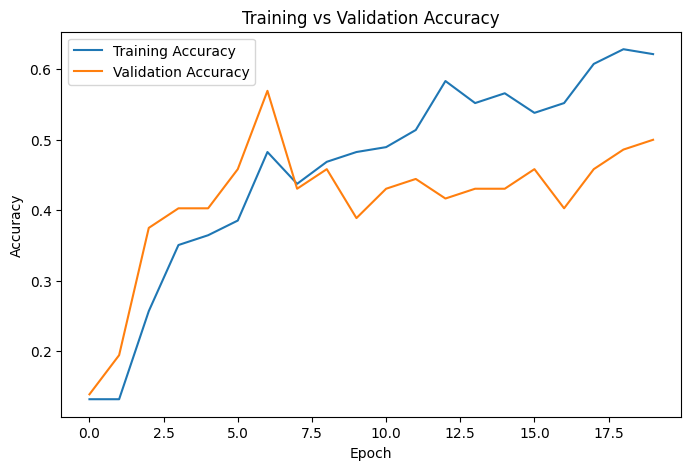

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()

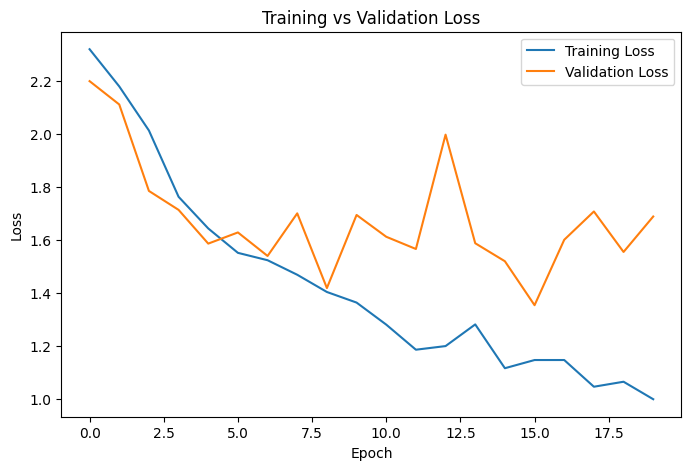

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [28]:
val_loss, val_accuracy = model.evaluate(val_ds)

print("Validation Loss:", val_loss)
print("Validation Accuracy:", val_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - accuracy: 0.5000 - loss: 1.6895
Validation Loss: 1.6895251274108887
Validation Accuracy: 0.5


In [29]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [30]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

                  precision    recall  f1-score   support

     apple fruit       0.20      0.12      0.15         8
    banana fruit       0.80      0.73      0.76        11
    cherry fruit       0.44      0.70      0.54        10
   chickoo fruit       0.57      0.44      0.50         9
    grapes fruit       0.44      0.80      0.57         5
      kiwi fruit       0.50      0.75      0.60         8
     mango fruit       0.00      0.00      0.00         7
    orange fruit       0.67      1.00      0.80         4
strawberry fruit       0.33      0.20      0.25        10

        accuracy                           0.50        72
       macro avg       0.44      0.53      0.46        72
    weighted avg       0.45      0.50      0.46        72



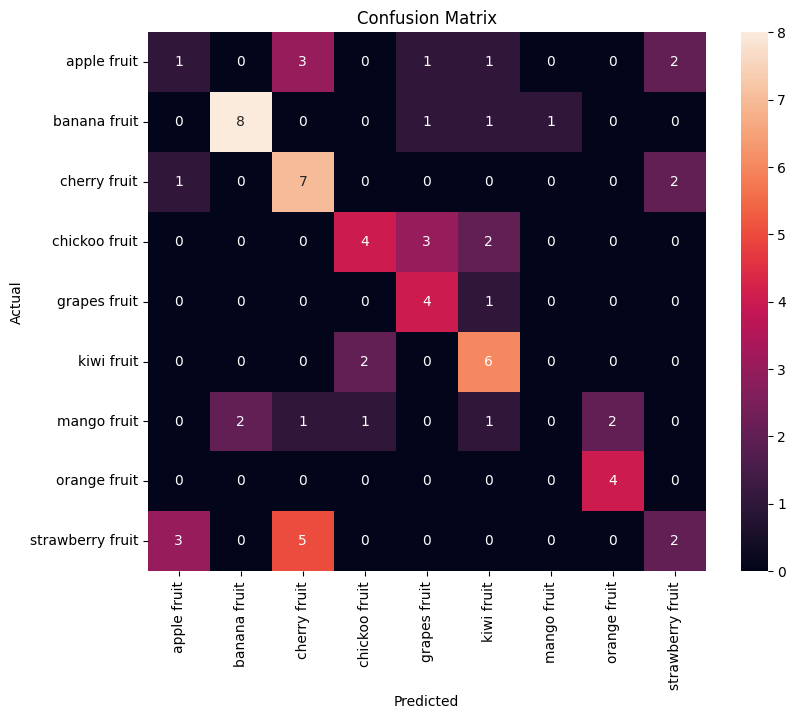

In [31]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [32]:
cm

array([[1, 0, 3, 0, 1, 1, 0, 0, 2],
       [0, 8, 0, 0, 1, 1, 1, 0, 0],
       [1, 0, 7, 0, 0, 0, 0, 0, 2],
       [0, 0, 0, 4, 3, 2, 0, 0, 0],
       [0, 0, 0, 0, 4, 1, 0, 0, 0],
       [0, 0, 0, 2, 0, 6, 0, 0, 0],
       [0, 2, 1, 1, 0, 1, 0, 2, 0],
       [0, 0, 0, 0, 0, 0, 0, 4, 0],
       [3, 0, 5, 0, 0, 0, 0, 0, 2]])

In [33]:
import matplotlib.pyplot as plt
import numpy as np

wrong_images = []
wrong_true = []
wrong_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    for i in range(len(labels)):
        if predicted_classes[i] != labels[i]:
            wrong_images.append(images[i].numpy())
            wrong_true.append(labels[i].numpy())
            wrong_pred.append(predicted_classes[i])

print("Misclassified images:", len(wrong_images))

Misclassified images: 36


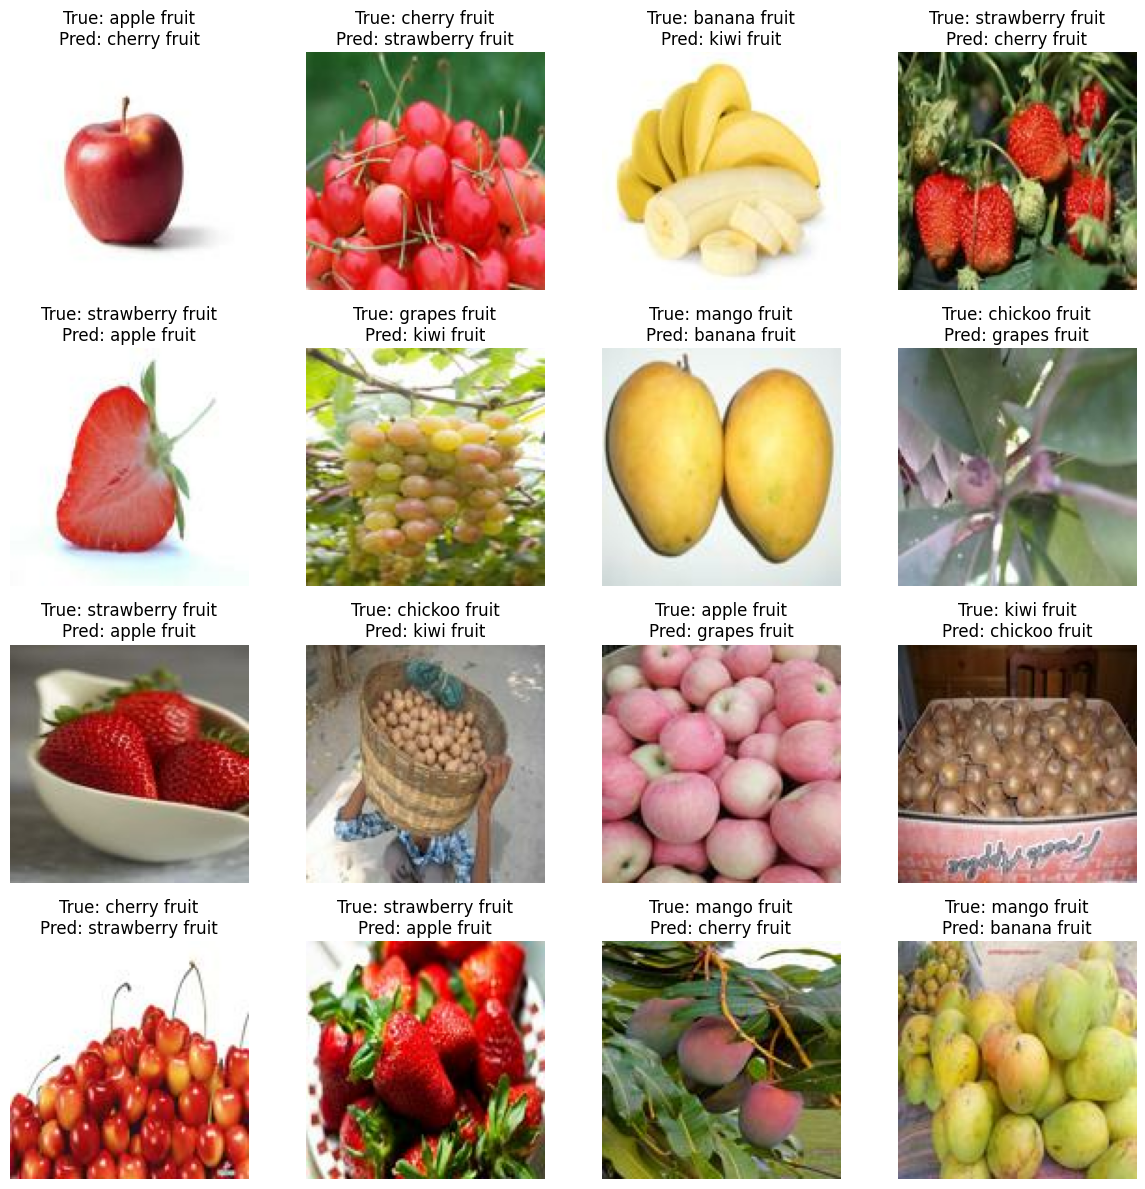

In [34]:
plt.figure(figsize=(12, 12))

num_images = min(16, len(wrong_images))

for i in range(num_images):
    ax = plt.subplot(4, 4, i + 1)

    plt.imshow(wrong_images[i])

    true_label = class_names[wrong_true[i]]
    pred_label = class_names[wrong_pred[i]]

    plt.title(f"True: {true_label}\nPred: {pred_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [35]:
baseline_params = model.count_params()
print("Baseline parameters:", baseline_params)

Baseline parameters: 3305801


In [36]:
model2 = Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    Conv2D(32, (3, 3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Activation('relu'),
    MaxPooling2D((2, 2)),
    tf.keras.layers.GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(class_names), activation='softmax')
])

In [37]:
model2.summary()

print("Model 1 parameters:", model.count_params())
print("Model 2 parameters:", model2.count_params())

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         1,161 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,817 (436.79 KB)

 Trainable params: 111,369 (435.04 KB)

 Non-trainable params: 448 (1.75 KB)

Model 1 parameters: 3305801
Model 2 parameters: 111817


In [38]:
model2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [40]:
history2 = model2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[early_stopping]
)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.2535 - loss: 2.0520 - val_accuracy: 0.1667 - val_loss: 2.1807
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.4132 - loss: 1.6312 - val_accuracy: 0.0556 - val_loss: 2.1982
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.4653 - loss: 1.5318 - val_accuracy: 0.1250 - val_loss: 2.1558
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.4167 - loss: 1.5027 - val_accuracy: 0.1806 - val_loss: 2.1574
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5208 - loss: 1.3604 - val_accuracy: 0.1806 - val_loss: 2.1940
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.5764 - loss: 1.2675 - val_accuracy: 0.1389 - val_loss: 2.1620
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5590 - loss: 1.2664 - val_accuracy: 0.1250 - val_loss: 2.2198
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.5799 - loss: 1.2704 - val_accuracy: 0.1250 - val_loss: 2.3344


In [41]:
model2.evaluate(val_ds)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 185ms/step - accuracy: 0.1250 - loss: 2.1558


[2.155780076980591, 0.125]

In [42]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [43]:
model3 = Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),
    tf.keras.layers.Rescaling(2, offset=-1),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    Dropout(0.3),
    Dense(
        len(class_names),
        activation='softmax'
    )
])

In [44]:
model3.summary()
print("Total parameters:", model3.count_params())

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 9)              │        11,529 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,269,513 (8.66 MB)

 Trainable params: 11,529 (45.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Total parameters: 2269513


In [45]:
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [46]:
early_stopping3 = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [47]:
history3 = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping3]
)

Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 1s/step - accuracy: 0.1875 - loss: 2.5199 - val_accuracy: 0.4028 - val_loss: 1.6245
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 649ms/step - accuracy: 0.4271 - loss: 1.6672 - val_accuracy: 0.6389 - val_loss: 1.1505
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 704ms/step - accuracy: 0.6667 - loss: 1.0533 - val_accuracy: 0.8056 - val_loss: 0.7730
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 571ms/step - accuracy: 0.7465 - loss: 0.7970 - val_accuracy: 0.8472 - val_loss: 0.6581
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 579ms/step - accuracy: 0.8194 - loss: 0.5950 - val_accuracy: 0.8611 - val_loss: 0.6063
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 621ms/step - accuracy: 0.8333 - loss: 0.5335 - val_accuracy: 0.8472 - val_loss: 0.5466
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 674ms/step - accuracy: 0.8750 - loss: 0.4028 - val_accuracy: 0.8611 - val_loss: 0.4868
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 501ms/step - accuracy: 0.8681 - loss: 0.3798 - val_accuracy: 0.8750 - val_loss:

In [48]:
val_loss3, val_accuracy3 = model3.evaluate(val_ds)

print("Validation Loss:", val_loss3)
print("Validation Accuracy:", val_accuracy3)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 219ms/step - accuracy: 0.8889 - loss: 0.4134
Validation Loss: 0.4134448766708374
Validation Accuracy: 0.8888888955116272


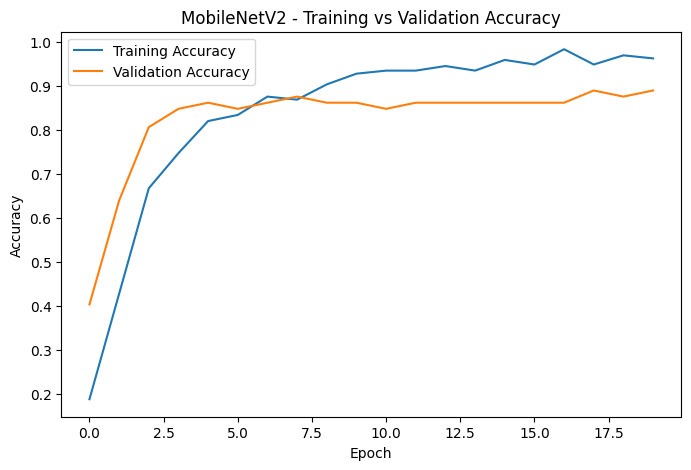

In [49]:
plt.figure(figsize=(8, 5))

plt.plot(history3.history['accuracy'], label='Training Accuracy')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MobileNetV2 - Training vs Validation Accuracy')
plt.legend()
plt.show()

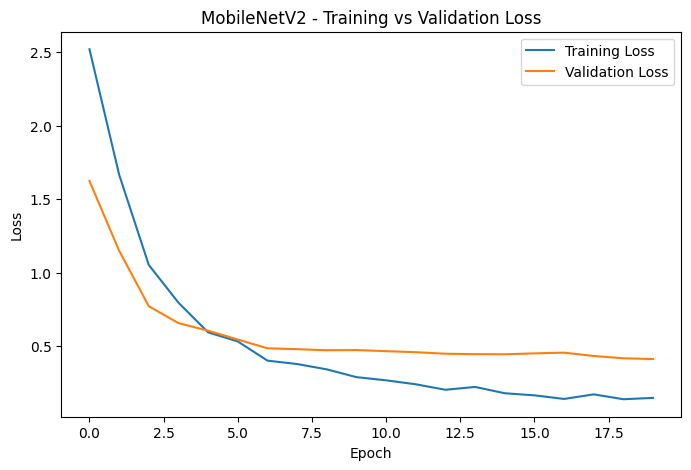

In [50]:
plt.figure(figsize=(8, 5))

plt.plot(history3.history['loss'], label='Training Loss')
plt.plot(history3.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MobileNetV2 - Training vs Validation Loss')
plt.legend()
plt.show()

In [51]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true3 = []
y_pred3 = []

for images, labels in val_ds:
    predictions = model3.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true3.extend(labels.numpy())
    y_pred3.extend(predicted_classes)

y_true3 = np.array(y_true3)
y_pred3 = np.array(y_pred3)

In [52]:
print(
    classification_report(
        y_true3,
        y_pred3,
        target_names=class_names
    )
)

                  precision    recall  f1-score   support

     apple fruit       0.80      1.00      0.89         8
    banana fruit       1.00      0.91      0.95        11
    cherry fruit       1.00      1.00      1.00        10
   chickoo fruit       0.73      0.89      0.80         9
    grapes fruit       0.71      1.00      0.83         5
      kiwi fruit       1.00      0.75      0.86         8
     mango fruit       1.00      0.57      0.73         7
    orange fruit       0.80      1.00      0.89         4
strawberry fruit       1.00      0.90      0.95        10

        accuracy                           0.89        72
       macro avg       0.89      0.89      0.88        72
    weighted avg       0.91      0.89      0.89        72



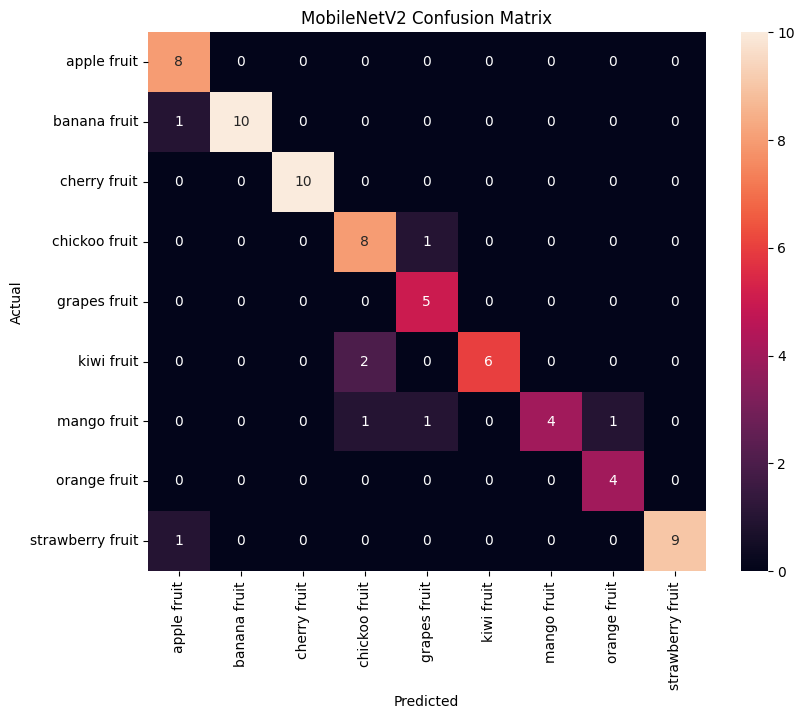

In [53]:
cm3 = confusion_matrix(y_true3, y_pred3)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm3,
    annot=True,
    fmt='d',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

In [54]:
cm3

array([[ 8,  0,  0,  0,  0,  0,  0,  0,  0],
       [ 1, 10,  0,  0,  0,  0,  0,  0,  0],
       [ 0,  0, 10,  0,  0,  0,  0,  0,  0],
       [ 0,  0,  0,  8,  1,  0,  0,  0,  0],
       [ 0,  0,  0,  0,  5,  0,  0,  0,  0],
       [ 0,  0,  0,  2,  0,  6,  0,  0,  0],
       [ 0,  0,  0,  1,  1,  0,  4,  1,  0],
       [ 0,  0,  0,  0,  0,  0,  0,  4,  0],
       [ 1,  0,  0,  0,  0,  0,  0,  0,  9]])

In [55]:
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [56]:
model3.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [57]:
early_stopping_ft = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True
)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-7
)

In [58]:
history_ft = model3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[early_stopping_ft, reduce_lr]
)

Epoch 1/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 14s 933ms/step - accuracy: 0.9722 - loss: 0.1218 - val_accuracy: 0.8750 - val_loss: 0.4324 - learning_rate: 1.0000e-05
Epoch 2/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 6s 655ms/step - accuracy: 0.9722 - loss: 0.1032 - val_accuracy: 0.8750 - val_loss: 0.4392 - learning_rate: 1.0000e-05
Epoch 3/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 658ms/step - accuracy: 0.9688 - loss: 0.1041 - val_accuracy: 0.8611 - val_loss: 0.4564 - learning_rate: 1.0000e-05
Epoch 4/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 7s 831ms/step - accuracy: 0.9861 - loss: 0.0716 - val_accuracy: 0.8611 - val_loss: 0.4525 - learning_rate: 2.0000e-06
Epoch 5/15
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 585ms/step - accuracy: 0.9722 - loss: 0.0993 - val_accuracy: 0.8611 - val_loss: 0.4542 - learning_rate: 2.0000e-06


In [61]:
model3.evaluate(val_ds)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 410ms/step - accuracy: 0.8750 - loss: 0.4324


[0.4324454069137573, 0.875]

In [62]:
val_loss_ft, val_acc_ft = model3.evaluate(val_ds)

print("Fine-tuned Validation Loss:", val_loss_ft)
print("Fine-tuned Validation Accuracy:", val_acc_ft)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 452ms/step - accuracy: 0.8750 - loss: 0.4324
Fine-tuned Validation Loss: 0.43244537711143494
Fine-tuned Validation Accuracy: 0.875


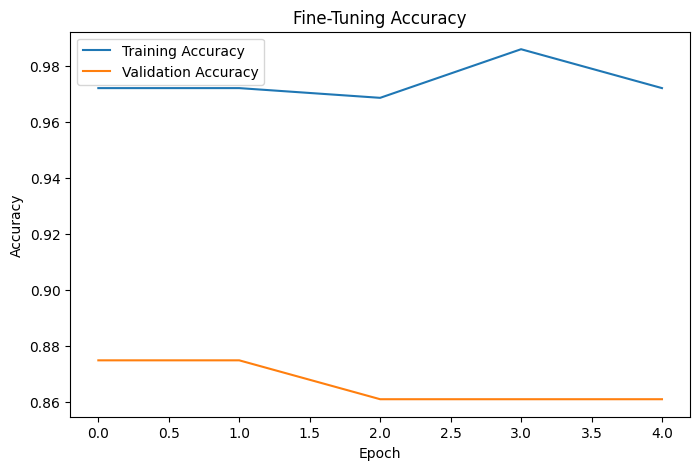

In [63]:
plt.figure(figsize=(8,5))
plt.plot(history_ft.history['accuracy'], label='Training Accuracy')
plt.plot(history_ft.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Fine-Tuning Accuracy')
plt.legend()
plt.show()

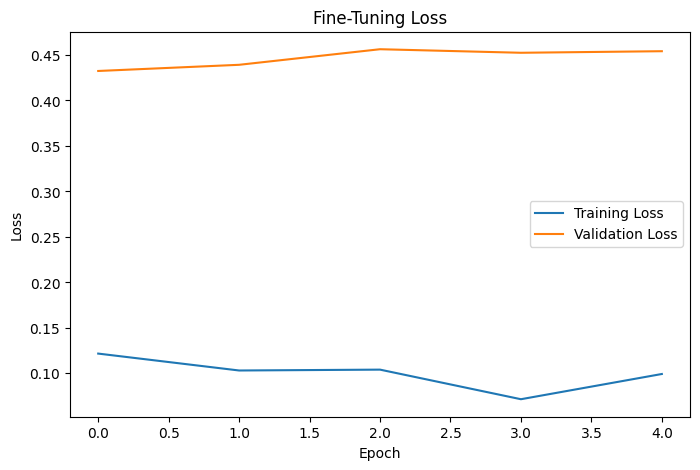

In [64]:
plt.figure(figsize=(8,5))
plt.plot(history_ft.history['loss'], label='Training Loss')
plt.plot(history_ft.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fine-Tuning Loss')
plt.legend()
plt.show()

In [65]:
final_loss, final_accuracy = model3.evaluate(val_ds, verbose=1)

print("Final Validation Loss:", final_loss)
print("Final Validation Accuracy:", final_accuracy)

3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 528ms/step - accuracy: 0.8750 - loss: 0.4324
Final Validation Loss: 0.43244537711143494
Final Validation Accuracy: 0.875


In [66]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model3.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(classification_report(
    y_true,
    y_pred,
    target_names=class_names
))

                  precision    recall  f1-score   support

     apple fruit       0.80      1.00      0.89         8
    banana fruit       1.00      0.91      0.95        11
    cherry fruit       1.00      0.90      0.95        10
   chickoo fruit       0.73      0.89      0.80         9
    grapes fruit       0.62      1.00      0.77         5
      kiwi fruit       1.00      0.75      0.86         8
     mango fruit       1.00      0.57      0.73         7
    orange fruit       0.80      1.00      0.89         4
strawberry fruit       1.00      0.90      0.95        10

        accuracy                           0.88        72
       macro avg       0.88      0.88      0.86        72
    weighted avg       0.91      0.88      0.88        72



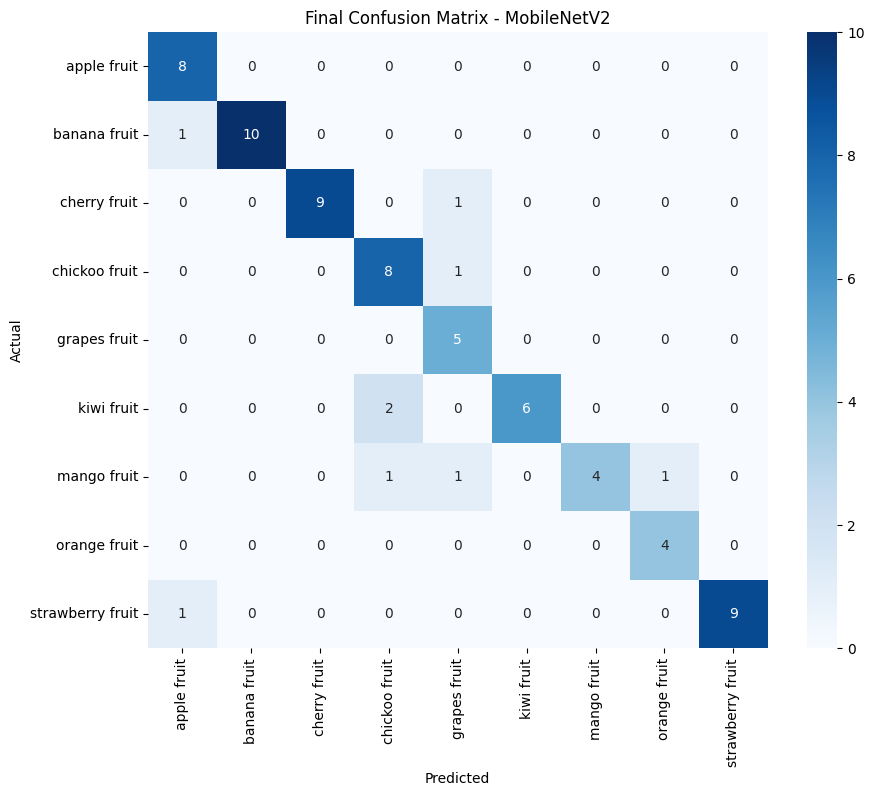

In [67]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Final Confusion Matrix - MobileNetV2")
plt.show()

In [68]:
from google.colab import files

uploaded = files.upload()

Saving canva-red-apple-fruit-MAFsWnPk_Vc.webp to canva-red-apple-fruit-MAFsWnPk_Vc (1).webp


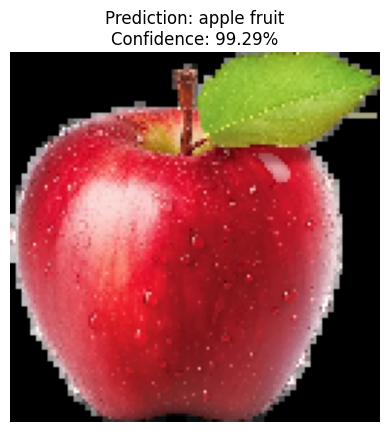

Predicted class: apple fruit
Confidence: 99.29%


In [69]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

filename = next(iter(uploaded))

img = load_img(
    filename,
    target_size=(128, 128)
)

img_array = img_to_array(img)

# Convert 0-255 → 0-1
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

prediction = model3.predict(img_array, verbose=0)

predicted_index = np.argmax(prediction[0])
predicted_class = class_names[predicted_index]
confidence = prediction[0][predicted_index]

plt.imshow(img)
plt.axis("off")
plt.title(
    f"Prediction: {predicted_class}\n"
    f"Confidence: {confidence*100:.2f}%"
)
plt.show()

print("Predicted class:", predicted_class)
print("Confidence:", f"{confidence*100:.2f}%")

In [70]:
model3.save("fruit_classifier_mobilenetv2.keras")

In [71]:
import os

print(
    "Model saved:",
    os.path.exists("fruit_classifier_mobilenetv2.keras")
)

Model saved: True
